# Baseline Comparison — Architecture Hierarchy

Compares all baseline architectures and the Vacuum Coulomb physics reference against
the current best GNN configurations on the canonical 110-protein test set
(836-protein training split, seed=42).

## Models

| Model | Architecture | Chemistry | Rounds |
|---|---|---|---|
| Surface DGCNN (geom-only) | Homogeneous surface point cloud | None — xyz + normals only | — |
| Surface DGCNN (chem) | Homogeneous surface point cloud | Nearest-atom element + residue one-hot | — |
| CNN3D | 3D U-Net on voxel grid | Full atom grid (element, position) | — |
| Vacuum Coulomb | Physics formula V = Σ qᵢ·560Å/rᵢ | PARSE partial charges (from PQR) | — |
| AttentionESPN 4/4/10 | Heterogeneous atom+query graph | Full (element, residue, bond, radial) | 4 AA / 4 AQ / 10 QQ |
| DistanceESPN 10/10/10 | Heterogeneous atom+query graph | Full (element, residue, bond, radial) | 10 AA / 10 AQ / 10 QQ |

All **trained** models exclude PARSE partial charges to maintain information parity.
Vacuum Coulomb uses partial charges directly — it is a physics upper-bound reference,
not a learned model. Its RMSE/MAE are on a completely different scale (~236 kT/e vs 2–4 kT/e
for trained models); RMSE/MAE panels use log scale.

The geom-only DGCNN eval data was deleted after being superseded — global metrics
are hardcoded from the recorded run (r=0.085, RMSE=3.98, MAE=3.23).

In [27]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path("../.." ).resolve()))

## 1. Configuration

In [28]:
THESIS_ROOT = Path("/home/student/thesis")
CKPT_ROOT   = THESIS_ROOT / "checkpoints"
EVAL_ROOT   = THESIS_ROOT / "model_eval"

# Each entry: label, short_label, color, test_metrics_path, per_protein_csv (or None), train_history
RUNS = [
    dict(
        label        = "DGCNN (geom-only)",
        short        = "DGCNN\ngeom-only",
        color        = "#aaaaaa",
        metrics_path = None,                 # eval data deleted — hardcoded below
        per_prot_csv = None,
        train_hist   = None,
        hardcoded    = dict(pearson_r=0.0849, rmse=3.9762, mae=3.2250, n_proteins=110),
    ),
    dict(
        label        = "DGCNN (chem)",
        short        = "DGCNN\nchem",
        color        = "#c07a3a",
        metrics_path = EVAL_ROOT / "baseline" / "surface_dgcnn_chem" / "test_metrics.json",
        per_prot_csv = EVAL_ROOT / "baseline" / "surface_dgcnn_chem" / "surface_dgcnn_results.csv",
        train_hist   = dict(
            path     = CKPT_ROOT / "baseline" / "surface_dgcnn_chem" / "train_history.json",
            r_col    = "val_r",
            loss_col = "val_loss",
        ),
    ),
    dict(
        label        = "CNN3D",
        short        = "CNN3D",
        color        = "#4878b0",
        metrics_path = EVAL_ROOT / "baseline" / "cnn3d" / "test_metrics.json",
        per_prot_csv = EVAL_ROOT / "baseline" / "cnn3d" / "cnn3d_results.csv",
        train_hist   = dict(
            path     = CKPT_ROOT / "baseline" / "cnn3d" / "train_history.json",
            r_col    = "val_r",
            loss_col = "val_loss",
        ),
    ),
    dict(
        label        = "Vacuum Coulomb",
        short        = "Vacuum\nCoulomb",
        color        = "#7b4ea0",
        metrics_path = EVAL_ROOT / "baseline" / "coulomb" / "test_metrics.json",
        per_prot_csv = None,     # per-protein data inline in test_metrics.json
        train_hist   = None,     # physics formula — no training
    ),
    dict(
        label        = "AttentionESPN 4/4/10",
        short        = "Attention\n4/4/10",
        color        = "#56a86b",
        metrics_path = CKPT_ROOT / "attention_v2_qq10" / "test_metrics.json",
        per_prot_csv = None,     # per-protein data is inline in test_metrics.json
        train_hist   = dict(
            path     = CKPT_ROOT / "attention_v2_qq10" / "metrics.csv",
            r_col    = "val_pearson_r",
            loss_col = "val_loss",
            is_csv   = True,
        ),
    ),
    dict(
        label        = "DistanceESPN 10/10/10",
        short        = "Distance\n10/10/10",
        color        = "#d95f02",
        metrics_path = CKPT_ROOT / "distance_v2_all10" / "test_metrics.json",
        per_prot_csv = None,
        train_hist   = dict(
            path     = CKPT_ROOT / "distance_v2_all10" / "metrics.csv",
            r_col    = "val_pearson_r",
            loss_col = "val_loss",
            is_csv   = True,
        ),
    ),
]

print(f"{'Model':<28}  {'Metrics':>8}  {'Per-prot':>9}  {'Train hist':>10}")
print("-" * 62)
for r in RUNS:
    has_m  = r["metrics_path"] is not None and Path(r["metrics_path"]).exists()
    has_m  = has_m or r.get("hardcoded") is not None
    has_pp = (r["per_prot_csv"] is not None and Path(r["per_prot_csv"]).exists()) \
             or (r["metrics_path"] is not None and Path(r["metrics_path"]).exists())
    has_th = r["train_hist"] is not None and Path(r["train_hist"]["path"]).exists()
    print(f"{r['label']:<28}  {'yes' if has_m else 'no':>8}  {'yes' if has_pp else 'no':>9}  {'yes' if has_th else 'no':>10}")

Model                          Metrics   Per-prot  Train hist
--------------------------------------------------------------
DGCNN (geom-only)                  yes         no          no
DGCNN (chem)                       yes        yes         yes
CNN3D                              yes        yes         yes
Vacuum Coulomb                     yes        yes          no
AttentionESPN 4/4/10               yes        yes         yes
DistanceESPN 10/10/10              yes        yes         yes


## 2. Load Test Metrics

In [29]:
def _load_global(run: dict) -> dict:
    if run.get("hardcoded"):
        return run["hardcoded"]
    with open(run["metrics_path"]) as f:
        data = json.load(f)
    return data["global"]


def _load_per_protein(run: dict) -> pd.Series | None:
    """Return Series of per-protein Pearson r values, or None if unavailable."""
    if run.get("hardcoded"):
        return None
    if run["per_prot_csv"] is not None:
        df = pd.read_csv(run["per_prot_csv"])
        return df["pearson_r"]
    # GNN models: per-protein data inline in test_metrics.json
    with open(run["metrics_path"]) as f:
        data = json.load(f)
    pp = data.get("per_protein", {})
    return pd.Series([v["pearson_r"] for v in pp.values()]) if pp else None


rows = []
for run in RUNS:
    g = _load_global(run)
    rows.append({
        "Model":      run["label"],
        "Pearson r":  g["pearson_r"],
        "RMSE":       g["rmse"],
        "MAE":        g["mae"],
        "N proteins": g["n_proteins"],
    })

global_df = pd.DataFrame(rows)
pd.set_option("display.float_format", "{:.4f}".format)
display(global_df)

,Model,Pearson r,RMSE,MAE,N proteins
0,DGCNN (geom-only),0.0849,3.9762,3.2250,110
1,DGCNN (chem),0.6685,3.1312,2.5354,110
2,CNN3D,0.8025,2.5776,2.0947,110
3,Vacuum Coulomb,0.8630,236.4440,205.7488,110
4,AttentionESPN 4/4/10,0.8900,2.4023,1.8589,110
5,DistanceESPN 10/10/10,0.8967,2.3036,1.7811,110


## 3. Global Metrics Bar Chart

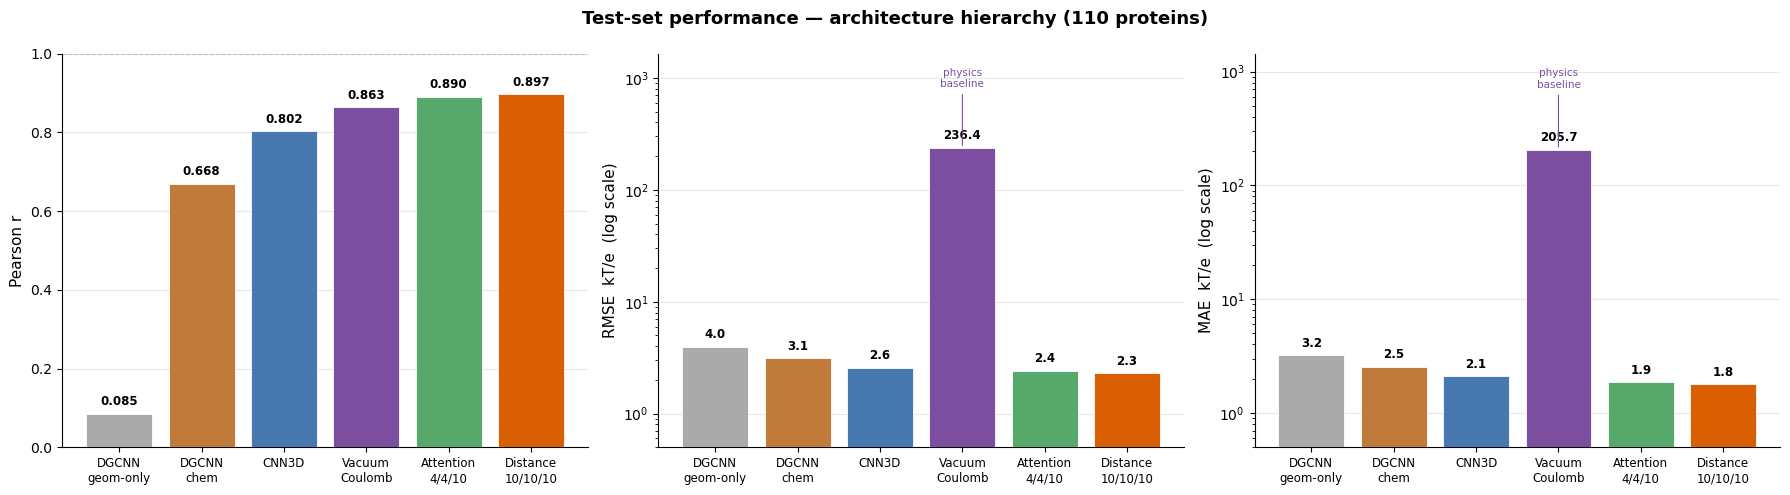

In [30]:
labels    = [r["short"] for r in RUNS]
colors    = [r["color"] for r in RUNS]
r_vals    = [_load_global(r)["pearson_r"] for r in RUNS]
rmse_vals = [_load_global(r)["rmse"] for r in RUNS]
mae_vals  = [_load_global(r)["mae"]  for r in RUNS]

x = np.arange(len(RUNS))
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Test-set performance — architecture hierarchy (110 proteins)",
             fontsize=13, fontweight="bold")

coulomb_idx = next(i for i, r in enumerate(RUNS) if r["label"] == "Vacuum Coulomb")

for ax, vals, ylabel, fmt, is_r, use_log in [
    (axes[0], r_vals,    "Pearson r",               "{:.3f}", True,  False),
    (axes[1], rmse_vals, "RMSE  kT/e  (log scale)", "{:.1f}", False, True),
    (axes[2], mae_vals,  "MAE  kT/e  (log scale)",  "{:.1f}", False, True),
]:
    bars = ax.bar(x, vals, color=colors, edgecolor="white", linewidth=0.6, zorder=3)
    ax.bar_label(bars, labels=[fmt.format(v) for v in vals],
                 padding=4, fontsize=8.5, fontweight="bold")
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=8.5)
    ax.grid(axis="y", alpha=0.3, zorder=0)
    ax.spines[["top", "right"]].set_visible(False)
    if use_log:
        ax.set_yscale("log")
        ax.set_ylim(0.5, max(vals) * 7)
        # Flag the physics baseline
        ax.annotate("physics\nbaseline", color="#7b4ea0", fontsize=7.5, ha="center",
                    xy=(coulomb_idx, vals[coulomb_idx]),
                    xytext=(coulomb_idx, vals[coulomb_idx] * 3.5),
                    arrowprops=dict(arrowstyle="-", color="#7b4ea0", lw=0.8))
    elif is_r:
        ax.set_ylim(0, 1.0)
        ax.axhline(1.0, color="gray", lw=0.8, ls="--", alpha=0.4)

plt.tight_layout()
plt.show()

## 4. Per-Protein Distribution

Violin + box plot of per-protein Pearson r across the test set.
Geometry-only DGCNN excluded (eval data deleted; global r=0.085 noted above).

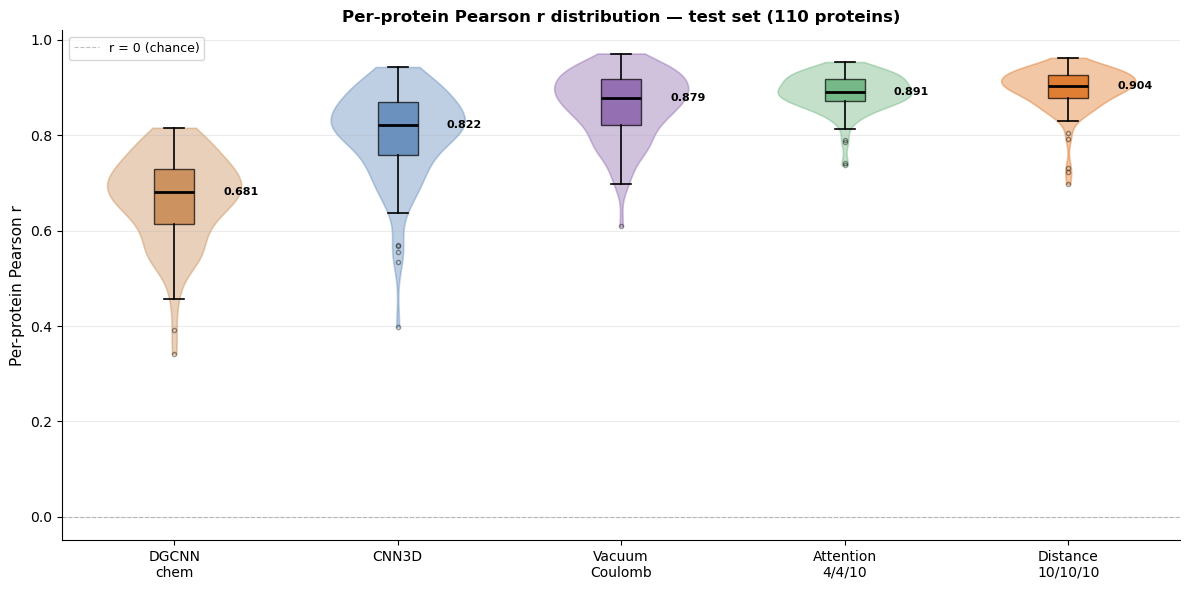

Model                            Mean    Median      Std     <0
------------------------------------------------------------
DGCNN (chem)                   0.6685    0.6808   0.0918      0
CNN3D                          0.8025    0.8216   0.0952      0
Vacuum Coulomb                 0.8630    0.8790   0.0701      0
AttentionESPN 4/4/10           0.8900    0.8913   0.0394      0
DistanceESPN 10/10/10          0.8967    0.9040   0.0450      0


In [31]:
pp_runs  = [r for r in RUNS if not r.get("hardcoded")]
pp_data  = [_load_per_protein(r).values for r in pp_runs]
pp_labels = [r["short"] for r in pp_runs]
pp_colors = [r["color"] for r in pp_runs]

fig, ax = plt.subplots(figsize=(12, 6))

vp = ax.violinplot(pp_data, positions=range(len(pp_runs)),
                   showmedians=False, showextrema=False, widths=0.6)
for body, color in zip(vp["bodies"], pp_colors):
    body.set_facecolor(color)
    body.set_alpha(0.35)
    body.set_edgecolor(color)
    body.set_linewidth(1.2)

bp = ax.boxplot(pp_data, positions=range(len(pp_runs)),
                widths=0.18, patch_artist=True,
                medianprops=dict(color="black", lw=2),
                whiskerprops=dict(lw=1.2),
                capprops=dict(lw=1.2),
                flierprops=dict(marker="o", markersize=3, alpha=0.4))
for patch, color in zip(bp["boxes"], pp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_xticks(range(len(pp_runs)))
ax.set_xticklabels(pp_labels, fontsize=10)
ax.set_ylabel("Per-protein Pearson r", fontsize=11)
ax.set_title("Per-protein Pearson r distribution — test set (110 proteins)",
             fontsize=12, fontweight="bold")
ax.axhline(0.0, color="gray", lw=0.8, ls="--", alpha=0.5, label="r = 0 (chance)")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)

# Annotate medians
for i, vals in enumerate(pp_data):
    med = np.median(vals)
    ax.text(i + 0.22, med, f"{med:.3f}", va="center", fontsize=8, fontweight="bold")

plt.tight_layout()
plt.show()

# Summary stats
print(f"{'Model':<28}  {'Mean':>7}  {'Median':>8}  {'Std':>7}  {'<0':>5}")
print("-" * 60)
for run, vals in zip(pp_runs, pp_data):
    s = pd.Series(vals)
    print(f"{run['label']:<28}  {s.mean():>7.4f}  {s.median():>8.4f}  "
          f"{s.std():>7.4f}  {(s < 0).sum():>5d}")

## 4b. Sorted Per-Protein Pearson r

Each model's 110 test proteins sorted from worst to best (independently).
The curve shape reveals tail behaviour: a steep left tail means catastrophic failures
on a few proteins; a flat right tail means a ceiling. Models are compared on the same
x-axis (rank 1–110 out of 110).

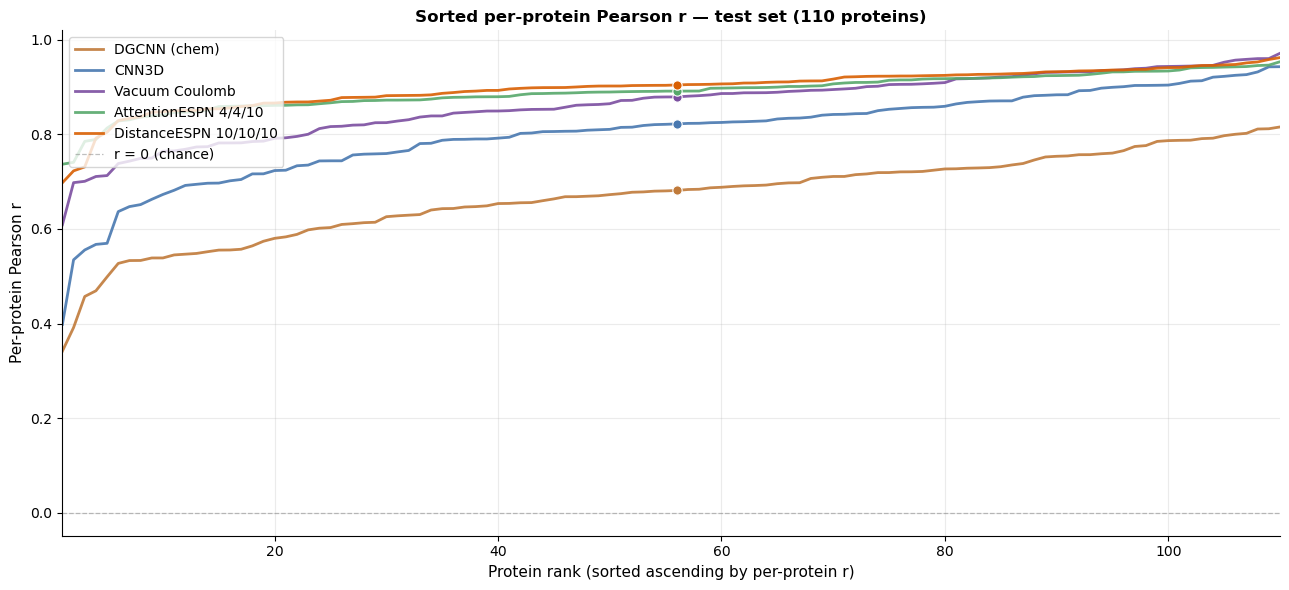


Model                         % above r=0   % above DGCNN chem
---------------------------------------------------------------
DGCNN (chem)                       100.0%                    —
CNN3D                              100.0%                 94.5%
Vacuum Coulomb                     100.0%                 94.5%
AttentionESPN 4/4/10               100.0%                100.0%
DistanceESPN 10/10/10              100.0%                 99.1%


In [32]:
fig, ax = plt.subplots(figsize=(13, 6))

for run in RUNS:
    pp = _load_per_protein(run)
    if pp is None:
        continue
    sorted_r = np.sort(pp.values)
    ranks = np.arange(1, len(sorted_r) + 1)
    ax.plot(ranks, sorted_r, color=run["color"], lw=2, label=run["label"], alpha=0.9)
    # Mark the median
    med_idx = len(sorted_r) // 2
    ax.scatter(ranks[med_idx], sorted_r[med_idx],
               color=run["color"], s=45, zorder=5, edgecolors="white", lw=0.8)

ax.axhline(0, color="gray", lw=0.9, ls="--", alpha=0.5, label="r = 0 (chance)")
ax.set_xlabel("Protein rank (sorted ascending by per-protein r)", fontsize=11)
ax.set_ylabel("Per-protein Pearson r", fontsize=11)
ax.set_title("Sorted per-protein Pearson r — test set (110 proteins)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="upper left")
ax.set_xlim(1, 110)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Count proteins where each model beats DGCNN (chem) as a rough "wins" table
dgcnn_pp = _load_per_protein(RUNS[1])
print(f"\n{'Model':<28}  {'% above r=0':>11}  {'% above DGCNN chem':>19}")
print("-" * 63)
for run in RUNS:
    pp = _load_per_protein(run)
    if pp is None:
        continue
    above_zero = (pp.values > 0).mean() * 100
    above_dgcnn = (pp.values > dgcnn_pp.values).mean() * 100 if run["label"] != "DGCNN (chem)" else float("nan")
    dgcnn_str = f"{above_dgcnn:>19.1f}%" if not np.isnan(above_dgcnn) else f"{'—':>19}"
    print(f"{run['label']:<28}  {above_zero:>10.1f}%  {dgcnn_str}")

## 5. Training Curves

Validation Pearson r over training epochs for all models with available history.
GNN models use `metrics.csv`; baseline models use `train_history.json`.

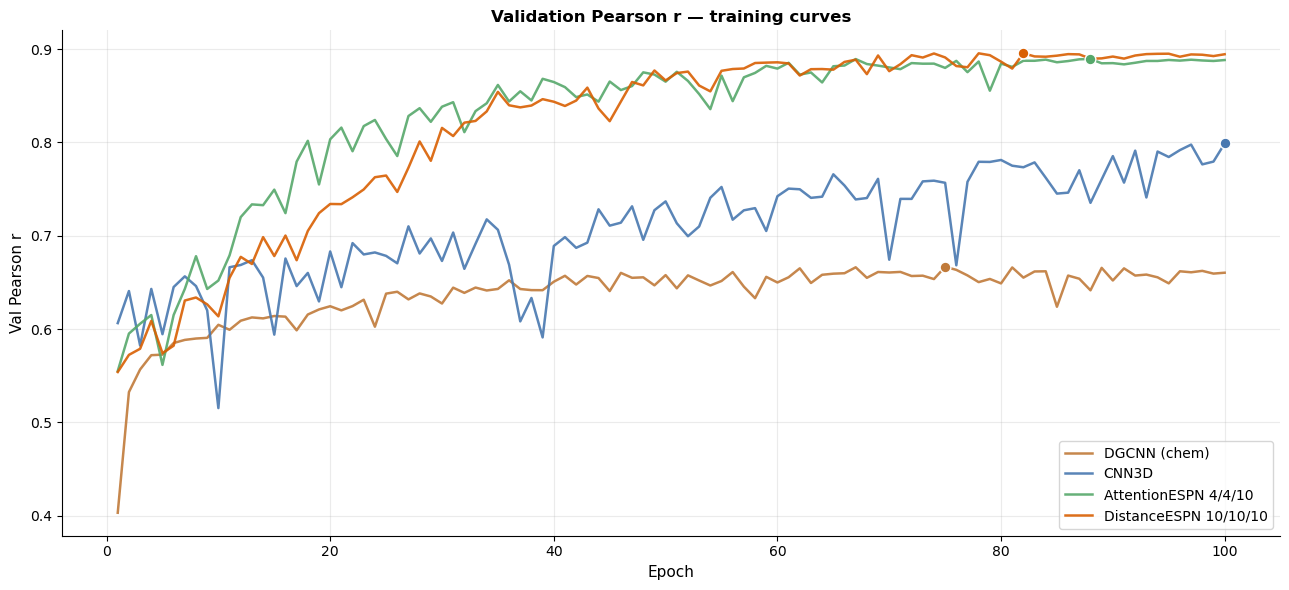

In [33]:
def _load_train_history(run: dict):
    """Return (epochs, val_r) arrays."""
    th = run.get("train_hist")
    if th is None or not Path(th["path"]).exists():
        return None, None
    if th.get("is_csv"):
        df = pd.read_csv(th["path"])
        return df["epoch"].values, df[th["r_col"]].values
    with open(th["path"]) as f:
        hist = json.load(f)
    epochs = [h["epoch"] for h in hist]
    r_vals = [h[th["r_col"]] for h in hist]
    return np.array(epochs), np.array(r_vals)


fig, ax = plt.subplots(figsize=(13, 6))

for run in RUNS:
    if run.get("hardcoded"):
        continue
    epochs, val_r = _load_train_history(run)
    if epochs is None:
        continue
    ax.plot(epochs, val_r, color=run["color"], lw=1.8, label=run["label"], alpha=0.9)
    # Mark best epoch
    best_idx = np.argmax(val_r)
    ax.scatter(epochs[best_idx], val_r[best_idx],
               color=run["color"], s=60, zorder=5, edgecolors="white", lw=1)

ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Val Pearson r", fontsize=11)
ax.set_title("Validation Pearson r — training curves", fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Per-Protein Scatter: Baselines vs GNN Champions

Each point is one test protein. x-axis = per-protein r for the GNN champion
(DistanceESPN 10/10/10); y-axis = per-protein r for a baseline.
Points above the diagonal would indicate the baseline *outperforming* the GNN
on that protein — useful for identifying failure modes.

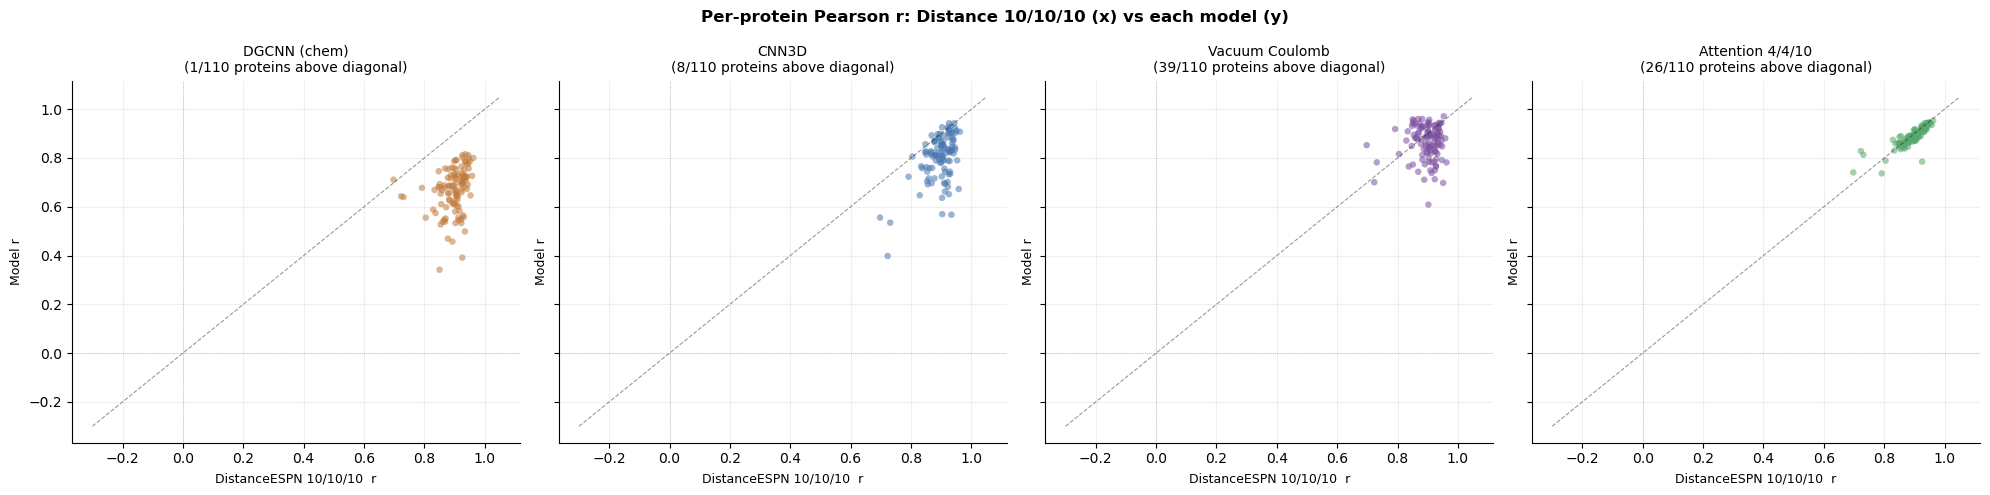

In [34]:
dist_pp = _load_per_protein(RUNS[5])   # DistanceESPN 10/10/10
attn_pp = _load_per_protein(RUNS[4])   # AttentionESPN 4/4/10

# Align by order (same 110 proteins in same order for all models)
baselines_pp = [
    ("DGCNN (chem)",     "#c07a3a", _load_per_protein(RUNS[1])),
    ("CNN3D",            "#4878b0", _load_per_protein(RUNS[2])),
    ("Vacuum Coulomb",   "#7b4ea0", _load_per_protein(RUNS[3])),
    ("Attention 4/4/10", "#56a86b", attn_pp),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle("Per-protein Pearson r: Distance 10/10/10 (x) vs each model (y)",
             fontsize=12, fontweight="bold")

diag = np.linspace(-0.3, 1.05, 50)
for ax, (label, color, pp) in zip(axes, baselines_pp):
    xs = dist_pp.values
    ys = pp.values
    ax.scatter(xs, ys, c=color, alpha=0.55, s=22, edgecolors="none")
    ax.plot(diag, diag, "k--", lw=0.8, alpha=0.4, label="y = x")
    above = (ys > xs).sum()
    ax.set_title(f"{label}\n({above}/110 proteins above diagonal)", fontsize=10)
    ax.set_xlabel("DistanceESPN 10/10/10  r", fontsize=9)
    ax.set_ylabel("Model r", fontsize=9)
    ax.axhline(0, color="gray", lw=0.6, ls=":", alpha=0.5)
    ax.axvline(0, color="gray", lw=0.6, ls=":", alpha=0.5)
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Summary

### Architecture hierarchy (test Pearson r, 110 proteins)

| Model | r | RMSE (kT/e) | Notes |
|---|---|---|---|
| DGCNN geom-only | 0.085 | 3.98 | Surface shape alone carries almost no ESP signal |
| DGCNN chem | 0.669 | 3.13 | Element + residue identity is the dominant signal |
| CNN3D | 0.803 | 2.58 | Volumetric 3D context over surface-only point cloud |
| Vacuum Coulomb† | 0.863 | **236** | Correct spatial pattern; no dielectric → RMSE ~100× worse than trained models |
| AttentionESPN 4/4/10 | 0.890 | 2.40 | Heterogeneous graph over unstructured voxel grid |
| DistanceESPN 10/10/10 | 0.897 | 2.30 | Best current config; distance beats attention at 836-protein scale |

*† Vacuum Coulomb uses PARSE partial charges directly — it is a physics upper-bound
reference, not a learned model. Its RMSE/MAE are excluded from the linear comparison
(log scale used in bar charts).*

### Key findings

**Finding 1 — Chemistry is load-bearing, geometry alone is insufficient.**  
The +0.584 jump from geom-only to chemistry DGCNN is the largest single step in the
hierarchy. Adding element and residue identity to surface vertices without any atomic
graph structure recovers the majority of signal available to the full CNN3D model.
This directly motivates the GNN approach: the model needs to reason about *which atom
is near this surface point*, not just *where the surface is*.

**Finding 2 — The physics Coulomb formula reveals what the GNN must learn beyond ranking.**  
Vacuum Coulomb (r=0.863) correctly localises ESP sign and relative magnitude in space,
matching CNN3D on Pearson r. Yet its RMSE=236 kT/e (vs 2–4 kT/e for trained models)
shows that correct *spatial ordering* is insufficient — the model must also learn
dielectric attenuation. The GNNs exceed Coulomb on both r **and** RMSE simultaneously,
confirming they learn to attenuate field contributions, not just rank them.

**Finding 3 — Graph topology adds substantial value over volumetric convolution.**  
CNN3D (r=0.803) and the GNN models (+0.09–0.10) use the same underlying chemical
information; the gap reflects the value of explicit molecular graph structure
(covalent bonds, radial neighbors) over isotropic 3D convolution. The graph
propagates information along chemically meaningful pathways rather than uniformly
through voxel space.

**Finding 4 — DistanceESPN currently beats AttentionESPN on 836 proteins.**  
The margin is small (+0.007 r), and the attention mechanism has more parameters
requiring more gradient signal to specialize. This result is expected to invert
on the full ~8,500-protein dataset.

**Finding 5 — Per-protein variance decreases with architecture quality.**  
DGCNN (chem) std=0.09; CNN3D std=0.10; GNNs std=0.07–0.08. The GNN models also
produce fewer catastrophically bad predictions (<0 r), indicating more consistent
generalisation rather than only higher average performance.

## 8. Sorted Per-Protein Pearson r

Each model's 110 test proteins sorted from worst to best (independently).
The curve shape reveals tail behaviour: a steep left tail means catastrophic failures
on a few proteins; a flat right tail means a ceiling.

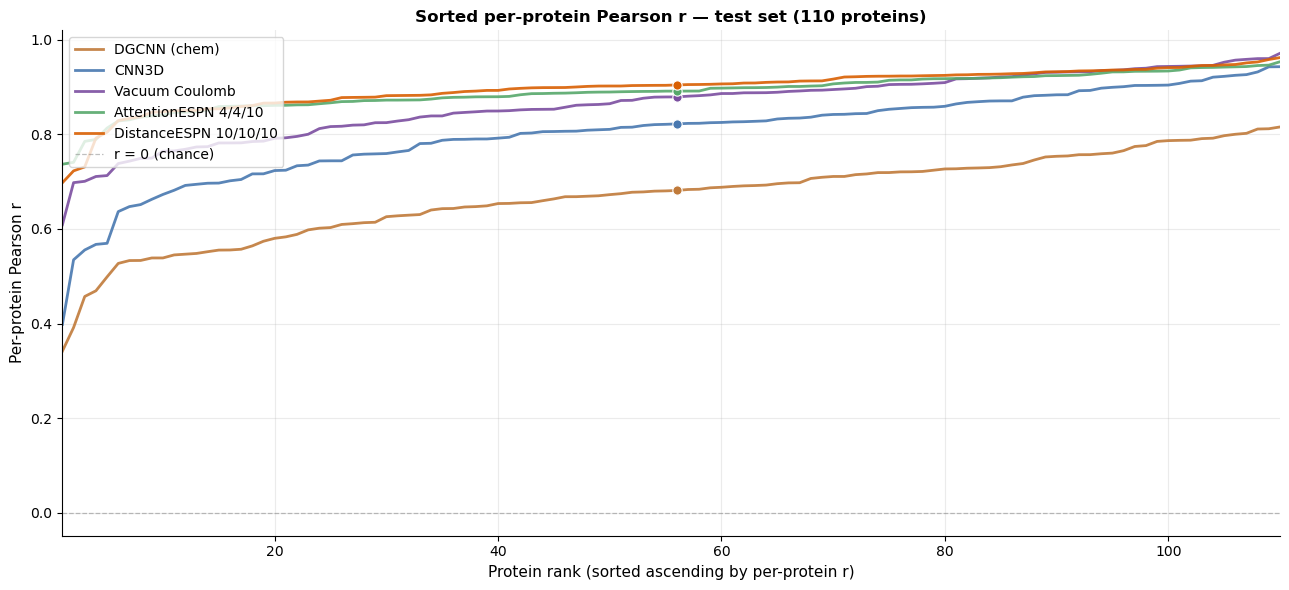


Model                         % above r=0   % above DGCNN chem
---------------------------------------------------------------
DGCNN (chem)                       100.0%                    —
CNN3D                              100.0%                 94.5%
Vacuum Coulomb                     100.0%                 94.5%
AttentionESPN 4/4/10               100.0%                100.0%
DistanceESPN 10/10/10              100.0%                 99.1%


In [35]:
fig, ax = plt.subplots(figsize=(13, 6))

for run in RUNS:
    pp = _load_per_protein(run)
    if pp is None:
        continue
    sorted_r = np.sort(pp.values)
    ranks = np.arange(1, len(sorted_r) + 1)
    ax.plot(ranks, sorted_r, color=run["color"], lw=2, label=run["label"], alpha=0.9)
    med_idx = len(sorted_r) // 2
    ax.scatter(ranks[med_idx], sorted_r[med_idx],
               color=run["color"], s=45, zorder=5, edgecolors="white", lw=0.8)

ax.axhline(0, color="gray", lw=0.9, ls="--", alpha=0.5, label="r = 0 (chance)")
ax.set_xlabel("Protein rank (sorted ascending by per-protein r)", fontsize=11)
ax.set_ylabel("Per-protein Pearson r", fontsize=11)
ax.set_title("Sorted per-protein Pearson r — test set (110 proteins)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10, loc="upper left")
ax.set_xlim(1, 110)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

dgcnn_pp = _load_per_protein(RUNS[1])
print(f"\n{'Model':<28}  {'% above r=0':>11}  {'% above DGCNN chem':>19}")
print("-" * 63)
for run in RUNS:
    pp = _load_per_protein(run)
    if pp is None:
        continue
    above_zero = (pp.values > 0).mean() * 100
    above_dgcnn = (pp.values > dgcnn_pp.values).mean() * 100 if run["label"] != "DGCNN (chem)" else float("nan")
    dgcnn_str = f"{above_dgcnn:>19.1f}%" if not np.isnan(above_dgcnn) else f"{'—':>19}"
    print(f"{run['label']:<28}  {above_zero:>10.1f}%  {dgcnn_str}")

## 9. Sorted Prediction Plots

True vs predicted ESP sorted by true value across all test-set query vertices.
Top panel: true ESP (blue) vs predicted ESP (orange ± 1σ band).
Bottom panel: signed residual (pred − true).

Over-smoothing shows as the predicted line collapsing toward zero at the extremes.
Systematic bias shows as a constant vertical offset in the residual panel.
Generated by `scripts/sorted_pred_baselines.py`.

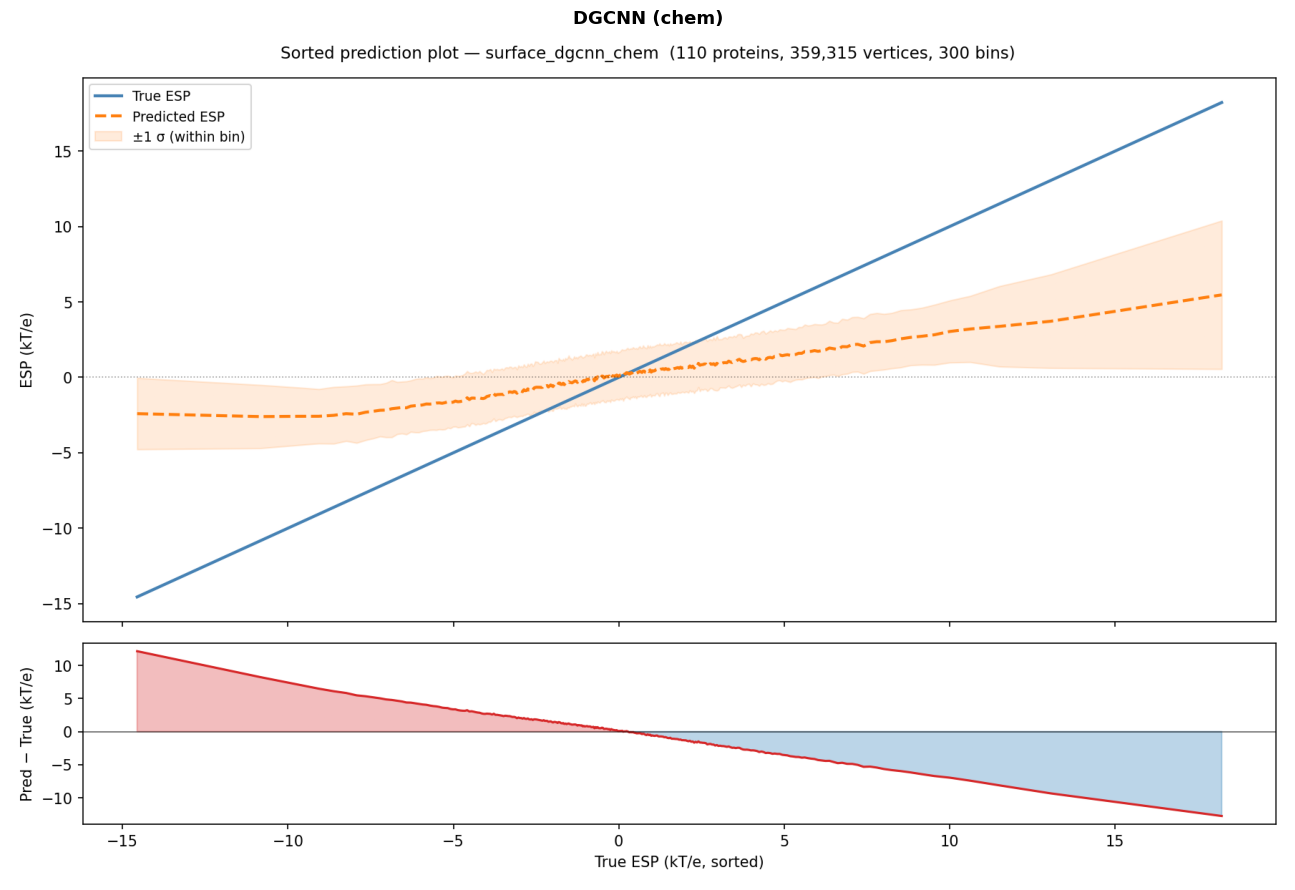

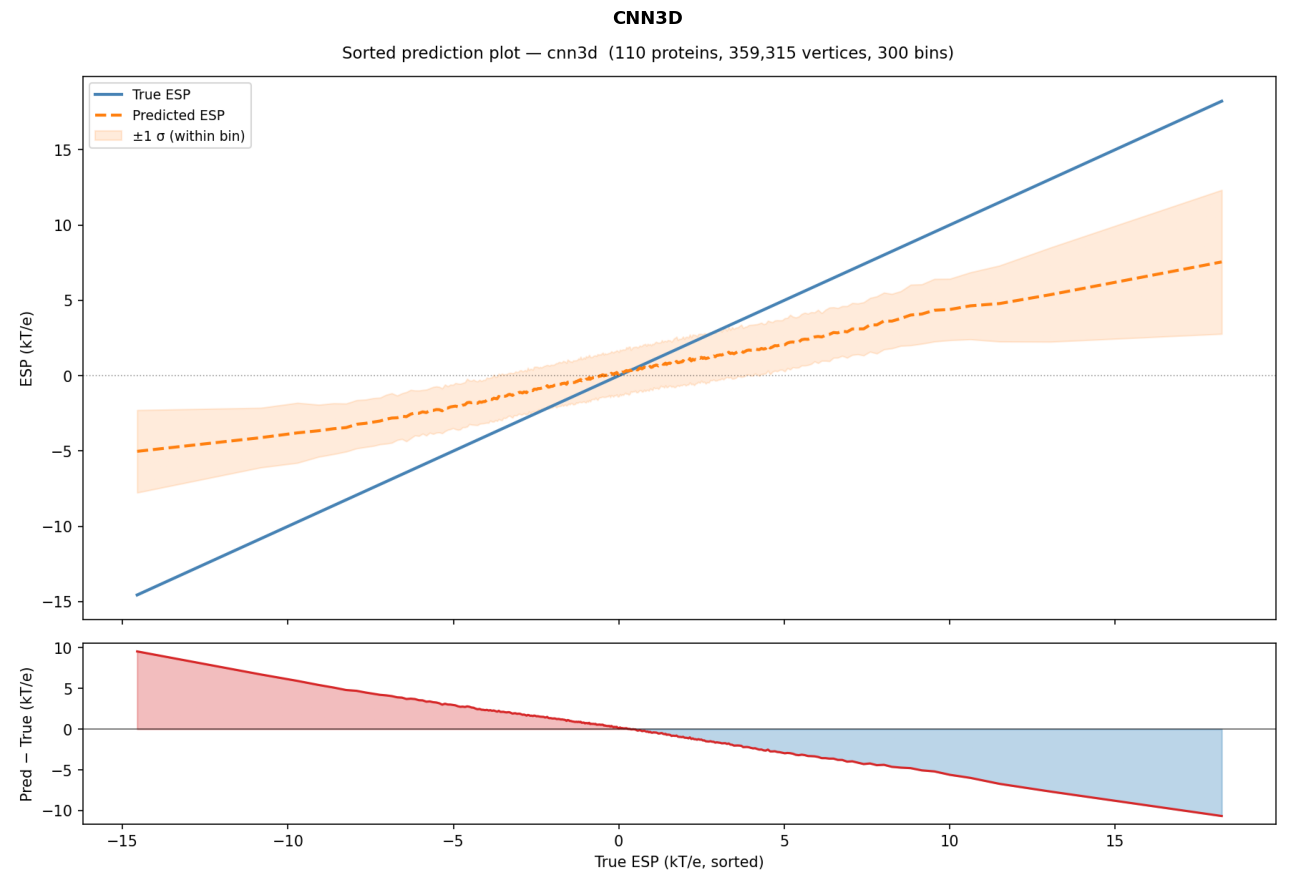

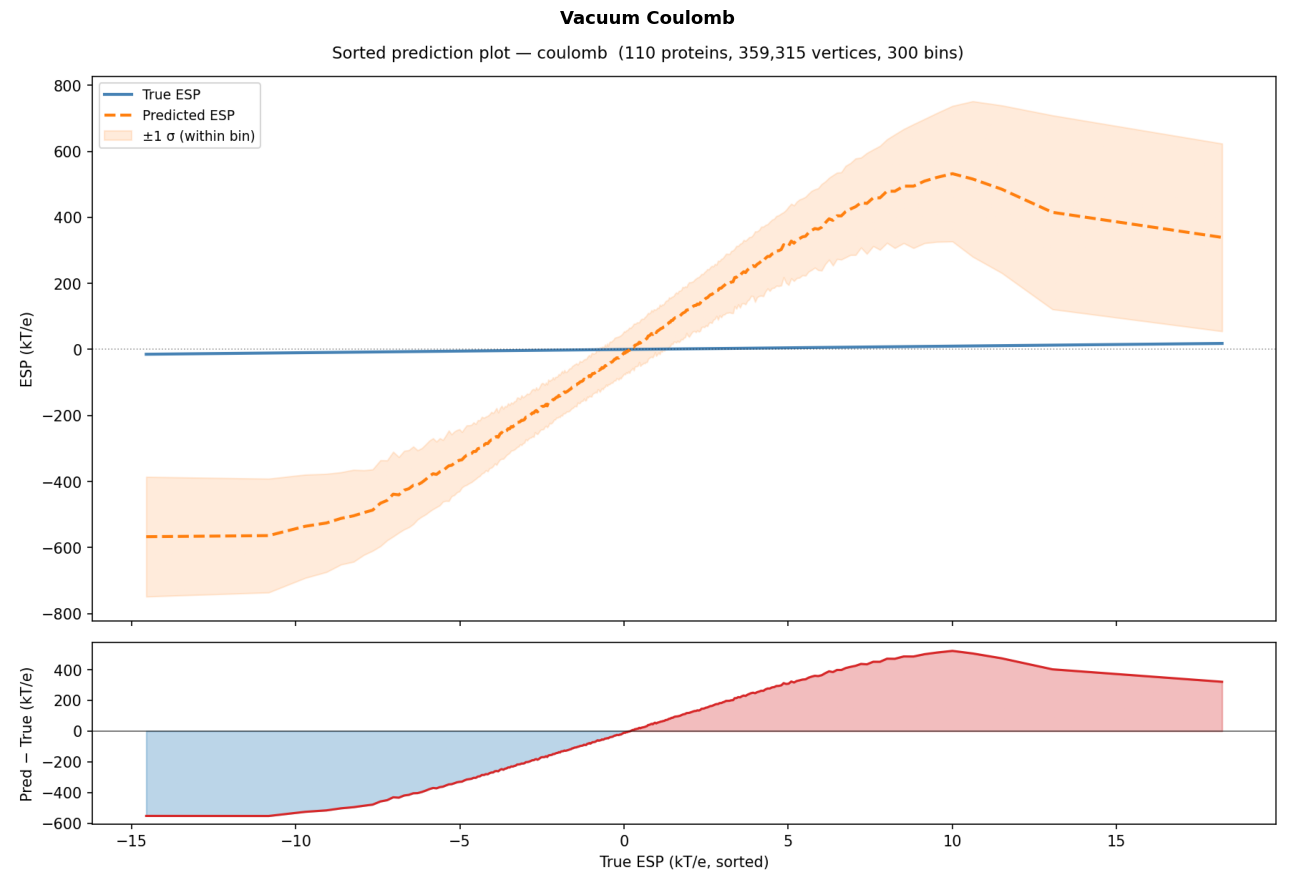

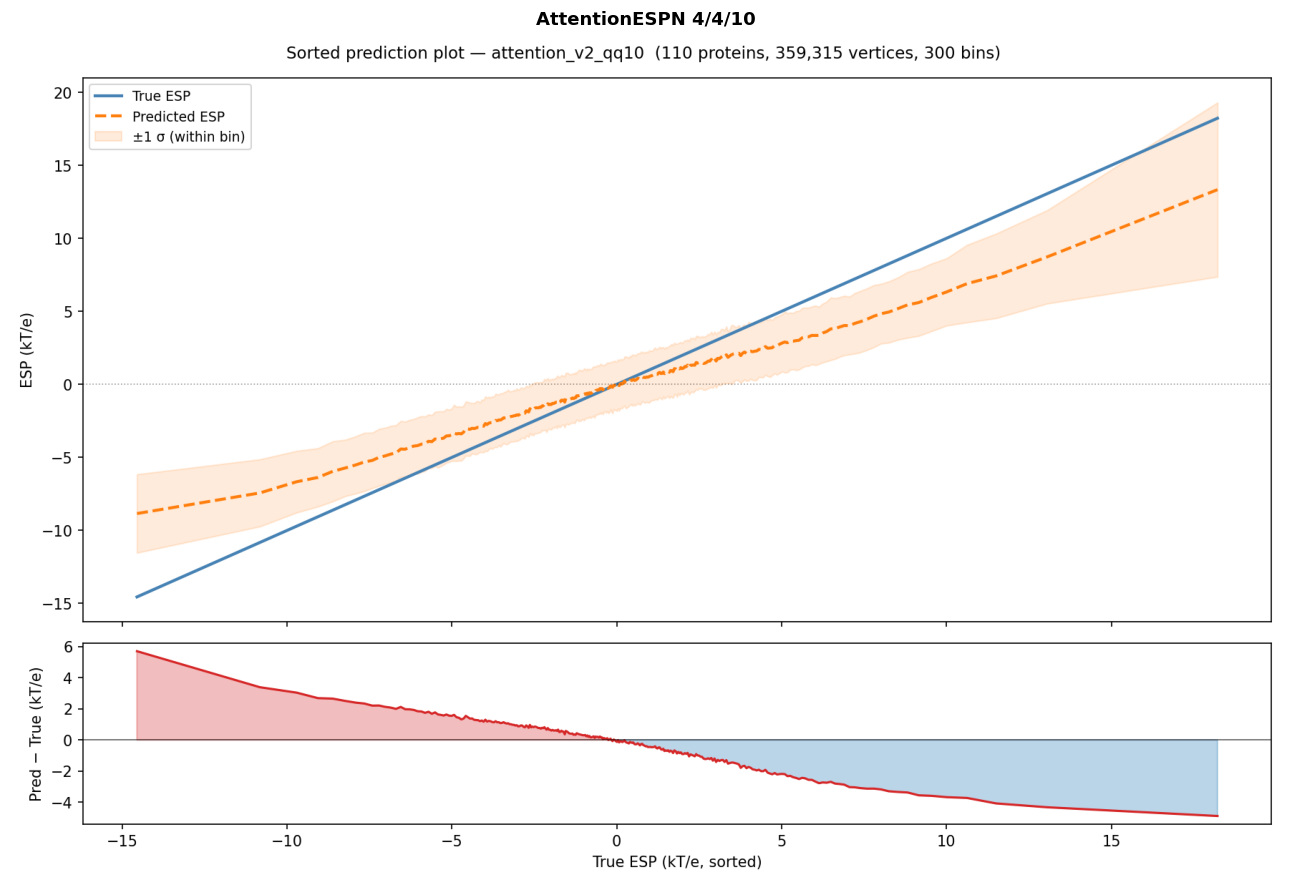

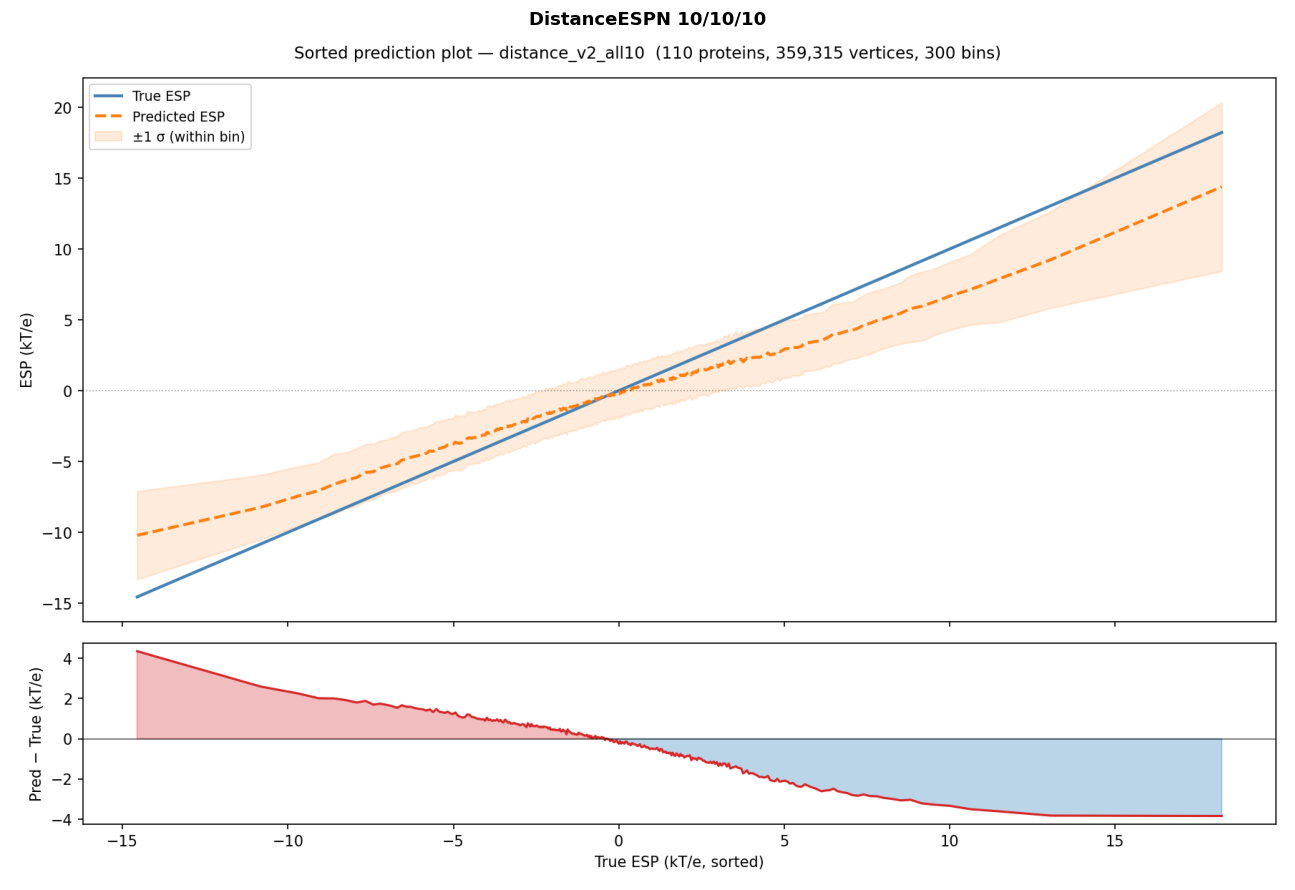

In [36]:
from matplotlib.image import imread

sorted_pred_plots = [
    ("DGCNN (chem)",
     EVAL_ROOT / "baseline" / "surface_dgcnn_chem" / "surface_dgcnn_chem_sorted_predictions.png"),
    ("CNN3D",
     EVAL_ROOT / "baseline" / "cnn3d" / "cnn3d_sorted_predictions.png"),
    ("Vacuum Coulomb",
     EVAL_ROOT / "baseline" / "coulomb" / "coulomb_sorted_predictions.png"),
    ("AttentionESPN 4/4/10",
     EVAL_ROOT / "attention_v2_qq10" / "sorted_predictions.png"),
    ("DistanceESPN 10/10/10",
     EVAL_ROOT / "distance_v2_all10" / "sorted_predictions.png"),
]

for label, path in sorted_pred_plots:
    if not path.exists():
        print(f"Missing: {path}")
        continue
    img = imread(str(path))
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(label, fontsize=13, fontweight="bold", pad=8)
    plt.tight_layout()
    plt.show()